# Boxing Dominance Analysis

## 1. Imports

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [65]:
df = pd.read_csv("../data/boxing_final_75.csv")

df.head()

,Fighter Name,Weight Class(es),Wins,Losses,Draws,No Contests,Total Fights,Record,KO Wins,KO %,KO Losses,Debut Year,Years Active,Championship Titles,BoxRec ID,Stoppage Win %,Decision Win %,Title Fight Wins,Title Fight Losses
0,Archie Moore,Light Heavyweight to Heavyweight,186,23,10,1,220,186-23-10 (132 KOs),132,60.0,7,1935,1935-1963,World Light Heavyweight,8995,71.0,29.0,10,2
1,Sugar Ray Robinson,Welterweight to Middleweight,174,19,6,2,201,174-19-6 (109 KOs),109,54.2,1,1940,1940-1965,World Welterweight/Middleweight,9625,62.6,37.4,14,7
2,Muhammad Ali,Heavyweight,56,5,0,0,61,56-5 (37 KOs),37,60.7,1,1960,1960-1981,WBA/WBC Heavyweight,180,66.1,33.9,22,3
3,Joe Louis,Heavyweight,66,3,0,0,69,66-3 (52 KOs),52,75.4,2,1934,1934-1951,World Heavyweight,9027,78.8,21.2,27,1
4,Ezzard Charles,Middleweight to Heavyweight,95,25,1,0,121,95-25-1 (52 KOs),52,43.0,7,1940,1940-1959,NBA Heavyweight,9012,54.7,45.3,9,4


### Replace "Present" with 2026 in Years Active

In [66]:
df["Years Active"] = df["Years Active"].str.replace("Present", "2026", regex=False)

## 3. Dataset Dimensions

In [67]:
df.shape

(75, 19)

## 4. Column Inspection

In [68]:
df.columns

Index(['Fighter Name', 'Weight Class(es)', 'Wins', 'Losses', 'Draws',
       'No Contests', 'Total Fights', 'Record', 'KO Wins', 'KO %', 'KO Losses',
       'Debut Year', 'Years Active', 'Championship Titles', 'BoxRec ID',
       'Stoppage Win %', 'Decision Win %', 'Title Fight Wins',
       'Title Fight Losses'],
      dtype='str')

In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Fighter Name         75 non-null     str    
 1   Weight Class(es)     75 non-null     str    
 2   Wins                 75 non-null     int64  
 3   Losses               75 non-null     int64  
 4   Draws                75 non-null     int64  
 5   No Contests          75 non-null     int64  
 6   Total Fights         75 non-null     int64  
 7   Record               75 non-null     str    
 8   KO Wins              75 non-null     int64  
 9   KO %                 75 non-null     float64
 10  KO Losses            75 non-null     int64  
 11  Debut Year           75 non-null     int64  
 12  Years Active         75 non-null     str    
 13  Championship Titles  74 non-null     str    
 14  BoxRec ID            75 non-null     int64  
 15  Stoppage Win %       75 non-null     float64
 16  Dec

## 5. Missing Values

In [70]:
df.isna().sum()

Fighter Name           0
Weight Class(es)       0
Wins                   0
Losses                 0
Draws                  0
No Contests            0
Total Fights           0
Record                 0
KO Wins                0
KO %                   0
KO Losses              0
Debut Year             0
Years Active           0
Championship Titles    1
BoxRec ID              0
Stoppage Win %         0
Decision Win %         0
Title Fight Wins       0
Title Fight Losses     0
dtype: int64

In [71]:
df.loc[
    df["Fighter Name"] == "Jimmy Bivins",
    "Championship Titles"
] = "None"

In [72]:
df.isna().sum()

Fighter Name           0
Weight Class(es)       0
Wins                   0
Losses                 0
Draws                  0
No Contests            0
Total Fights           0
Record                 0
KO Wins                0
KO %                   0
KO Losses              0
Debut Year             0
Years Active           0
Championship Titles    0
BoxRec ID              0
Stoppage Win %         0
Decision Win %         0
Title Fight Wins       0
Title Fight Losses     0
dtype: int64

## 6. Duplicate Checks

In [73]:
df.duplicated().sum()

np.int64(0)

In [74]:
df["Fighter Name"].duplicated().sum()

np.int64(0)

## 7. Data Validation

In [75]:
df[df["KO Wins"] > df["Wins"]]

,Fighter Name,Weight Class(es),Wins,Losses,Draws,No Contests,Total Fights,Record,KO Wins,KO %,KO Losses,Debut Year,Years Active,Championship Titles,BoxRec ID,Stoppage Win %,Decision Win %,Title Fight Wins,Title Fight Losses


In [76]:
df[df["Title Fight Wins"] > df["Wins"]]

,Fighter Name,Weight Class(es),Wins,Losses,Draws,No Contests,Total Fights,Record,KO Wins,KO %,KO Losses,Debut Year,Years Active,Championship Titles,BoxRec ID,Stoppage Win %,Decision Win %,Title Fight Wins,Title Fight Losses


In [77]:
df[(df["KO %"] < 0) | (df["KO %"] > 100)]

,Fighter Name,Weight Class(es),Wins,Losses,Draws,No Contests,Total Fights,Record,KO Wins,KO %,KO Losses,Debut Year,Years Active,Championship Titles,BoxRec ID,Stoppage Win %,Decision Win %,Title Fight Wins,Title Fight Losses


In [78]:
df[
    (df["Stoppage Win %"] < 0)
    | (df["Stoppage Win %"] > 100)
]

,Fighter Name,Weight Class(es),Wins,Losses,Draws,No Contests,Total Fights,Record,KO Wins,KO %,KO Losses,Debut Year,Years Active,Championship Titles,BoxRec ID,Stoppage Win %,Decision Win %,Title Fight Wins,Title Fight Losses


In [79]:
df[
    (df["Decision Win %"] < 0)
    | (df["Decision Win %"] > 100)
]

,Fighter Name,Weight Class(es),Wins,Losses,Draws,No Contests,Total Fights,Record,KO Wins,KO %,KO Losses,Debut Year,Years Active,Championship Titles,BoxRec ID,Stoppage Win %,Decision Win %,Title Fight Wins,Title Fight Losses


In [80]:
df["Calculated Total Fights"] = (
    df["Wins"]
    + df["Losses"]
    + df["Draws"]
    + df["No Contests"]
)

In [81]:
df[
    df["Calculated Total Fights"] != df["Total Fights"]
][
    [
        "Fighter Name",
        "Total Fights",
        "Calculated Total Fights"
    ]
]

,Fighter Name,Total Fights,Calculated Total Fights


In [99]:
df.drop(columns="Calculated Total Fights", inplace=True)

## 8. Descriptive Statistics

In [82]:
df.describe()

,Wins,Losses,Draws,No Contests,Total Fights,KO Wins,KO %,KO Losses,Debut Year,BoxRec ID,Stoppage Win %,Decision Win %,Title Fight Wins,Title Fight Losses,Calculated Total Fights
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000
mean,75.546667,9.413333,3.826667,0.640000,89.426667,42.626667,56.134667,1.840000,1967.480000,167646.106667,63.076000,36.925333,13.186667,2.786667,89.426667
std,54.936153,10.770447,8.473127,1.539041,70.678406,26.003520,18.685234,2.060176,35.559376,268544.603450,18.282911,18.281567,7.238585,2.406598,70.678406
min,18.000000,0.000000,0.000000,0.000000,21.000000,11.000000,8.700000,0.000000,1891.000000,43.000000,12.700000,4.800000,0.000000,0.000000,21.000000
25%,38.000000,2.000000,0.000000,0.000000,41.000000,26.500000,43.500000,0.000000,1940.000000,8839.500000,50.000000,22.550000,8.000000,1.000000,41.000000
50%,56.000000,6.000000,1.000000,0.000000,67.000000,33.000000,58.700000,1.000000,1968.000000,9035.000000,66.200000,33.800000,12.000000,2.000000,67.000000
75%,88.000000,11.500000,3.000000,0.500000,111.500000,52.000000,71.900000,3.000000,2004.500000,352795.000000,77.450000,50.000000,17.500000,4.000000,111.500000
max,261.000000,60.000000,53.000000,8.000000,345.000000,132.000000,90.900000,7.000000,2017.000000,790719.000000,95.200000,87.300000,31.000000,11.000000,345.000000


In [83]:
df[
    [
        "Wins",
        "Losses",
        "Draws",
        "No Contests",
        "Total Fights",
        "KO Wins",
        "KO %",
        "KO Losses",
        "Debut Year",
        "Years Active",
        "Stoppage Win %",
        "Decision Win %",
        "Title Fight Wins",
        "Title Fight Losses"
    ]
].describe()

,Wins,Losses,Draws,No Contests,Total Fights,KO Wins,KO %,KO Losses,Debut Year,Stoppage Win %,Decision Win %,Title Fight Wins,Title Fight Losses
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000
mean,75.546667,9.413333,3.826667,0.640000,89.426667,42.626667,56.134667,1.840000,1967.480000,63.076000,36.925333,13.186667,2.786667
std,54.936153,10.770447,8.473127,1.539041,70.678406,26.003520,18.685234,2.060176,35.559376,18.282911,18.281567,7.238585,2.406598
min,18.000000,0.000000,0.000000,0.000000,21.000000,11.000000,8.700000,0.000000,1891.000000,12.700000,4.800000,0.000000,0.000000
25%,38.000000,2.000000,0.000000,0.000000,41.000000,26.500000,43.500000,0.000000,1940.000000,50.000000,22.550000,8.000000,1.000000
50%,56.000000,6.000000,1.000000,0.000000,67.000000,33.000000,58.700000,1.000000,1968.000000,66.200000,33.800000,12.000000,2.000000
75%,88.000000,11.500000,3.000000,0.500000,111.500000,52.000000,71.900000,3.000000,2004.500000,77.450000,50.000000,17.500000,4.000000
max,261.000000,60.000000,53.000000,8.000000,345.000000,132.000000,90.900000,7.000000,2017.000000,95.200000,87.300000,31.000000,11.000000


## 9. Create Derived Metrics

In [100]:
# Calculate career length in years
career_years = df["Years Active"].str.split("-", expand=True)

df["Career Length"] = (
    pd.to_numeric(career_years[1])
    - pd.to_numeric(career_years[0])
)

In [101]:
df[
    ["Fighter Name", "Years Active", "Career Length"]
].head(10)

,Fighter Name,Years Active,Career Length
0,Archie Moore,1935-1963,28
1,Sugar Ray Robinson,1940-1965,25
2,Muhammad Ali,1960-1981,21
3,Joe Louis,1934-1951,17
4,Ezzard Charles,1940-1959,19
5,Harry Greb,1913-1926,13
6,Carlos Monzon,1963-1977,14
7,Tony Canzoneri,1925-1939,14
8,Dick Tiger,1952-1970,18
9,Carlos Ortiz,1955-1972,17


In [84]:
df["Win %"] = (
    df["Wins"]
    / df["Total Fights"]
    * 100
)

In [85]:
df["Loss %"] = (
    df["Losses"]
    / df["Total Fights"]
    * 100
)

In [86]:
df["Title Fight Total"] = (
    df["Title Fight Wins"]
    + df["Title Fight Losses"]
)

In [87]:
df["Title Fight Win %"] = np.where(
    df["Title Fight Total"] > 0,
    (
        df["Title Fight Wins"]
        / df["Title Fight Total"]
        * 100
    ),
    0
)

In [88]:
df[
    [
        "Fighter Name",
        "Win %",
        "Loss %",
        "Title Fight Total",
        "Title Fight Win %"
    ]
].head(10)

,Fighter Name,Win %,Loss %,Title Fight Total,Title Fight Win %
0,Archie Moore,84.545455,10.454545,12,83.333333
1,Sugar Ray Robinson,86.567164,9.452736,21,66.666667
2,Muhammad Ali,91.803279,8.196721,25,88.000000
3,Joe Louis,95.652174,4.347826,28,96.428571
4,Ezzard Charles,78.512397,20.661157,13,69.230769
5,Harry Greb,87.290970,6.020067,7,71.428571
6,Carlos Monzon,87.000000,3.000000,15,100.000000
7,Tony Canzoneri,80.571429,13.714286,21,57.142857
8,Dick Tiger,73.170732,23.170732,9,66.666667
9,Carlos Ortiz,87.142857,10.000000,18,77.777778


## 10. Top Fighters by Individual Metrics

In [89]:
df.sort_values(
    "Win %",
    ascending=False
)[
    ["Fighter Name", "Win %"]
].head(10)

,Fighter Name,Win %
71,David Benavidez,100.000000
73,Shakur Stevenson,100.000000
59,Oleksandr Usyk,100.000000
50,Floyd Mayweather,100.000000
57,Naoya Inoue,100.000000
55,Terence Crawford,100.000000
52,Andre Ward,100.000000
69,Jermall Charlo,100.000000
15,Rocky Marciano,100.000000
72,Devin Haney,97.058824


In [90]:
df.sort_values(
    "KO %",
    ascending=False
)[
    ["Fighter Name", "KO %"]
].head(10)

,Fighter Name,KO %
58,Artur Beterbiev,90.9
64,Gervonta Davis,90.3
15,Rocky Marciano,87.8
48,George Foreman,84.0
61,Gennadiy Golovkin,82.2
57,Naoya Inoue,81.8
71,David Benavidez,81.3
66,Anthony Joshua,79.4
21,Marvin Hagler,77.6
3,Joe Louis,75.4


In [91]:
df.sort_values(
    "Stoppage Win %",
    ascending=False
)[
    ["Fighter Name", "Stoppage Win %"]
].head(10)

,Fighter Name,Stoppage Win %
58,Artur Beterbiev,95.2
64,Gervonta Davis,93.3
66,Anthony Joshua,90.0
48,George Foreman,89.5
61,Gennadiy Golovkin,88.1
15,Rocky Marciano,87.8
40,Joe Frazier,84.4
21,Marvin Hagler,83.9
67,Emanuel Navarrete,82.5
37,Bob Foster,82.1


In [92]:
df.sort_values(
    "Title Fight Wins",
    ascending=False
)[
    ["Fighter Name", "Title Fight Wins"]
].head(10)

,Fighter Name,Title Fight Wins
33,Julio Cesar Chavez,31
10,Sam Langford,30
3,Joe Louis,27
50,Floyd Mayweather,26
57,Naoya Inoue,26
53,Roy Jones Jr,25
56,Saul Alvarez,24
22,Harry Wills,24
35,Oscar De La Hoya,24
11,Henry Armstrong,24


In [93]:
df.sort_values(
    "Title Fight Win %",
    ascending=False
)[
    [
        "Fighter Name",
        "Title Fight Total",
        "Title Fight Win %"
    ]
].head(10)

,Fighter Name,Title Fight Total,Title Fight Win %
6,Carlos Monzon,15,100.0
64,Gervonta Davis,7,100.0
59,Oleksandr Usyk,14,100.0
72,Devin Haney,9,100.0
71,David Benavidez,5,100.0
55,Terence Crawford,20,100.0
52,Andre Ward,12,100.0
69,Jermall Charlo,8,100.0
73,Shakur Stevenson,9,100.0
29,Gene Tunney,3,100.0


In [102]:
df.sort_values(
    "Career Length",
    ascending=False
)[
    ["Fighter Name", "Years Active", "Career Length"]
].head(10)

,Fighter Name,Years Active,Career Length
36,Jack Johnson,1897-1931,34
38,Roberto Duran,1968-2001,33
51,Manny Pacquiao,1995-2025,30
41,Thomas Hearns,1977-2006,29
28,Larry Holmes,1973-2002,29
53,Roy Jones Jr,1989-2018,29
43,Azumah Nelson,1979-2008,29
48,George Foreman,1969-1997,28
0,Archie Moore,1935-1963,28
54,Bernard Hopkins,1988-2016,28


## 11. Basic Visualisations

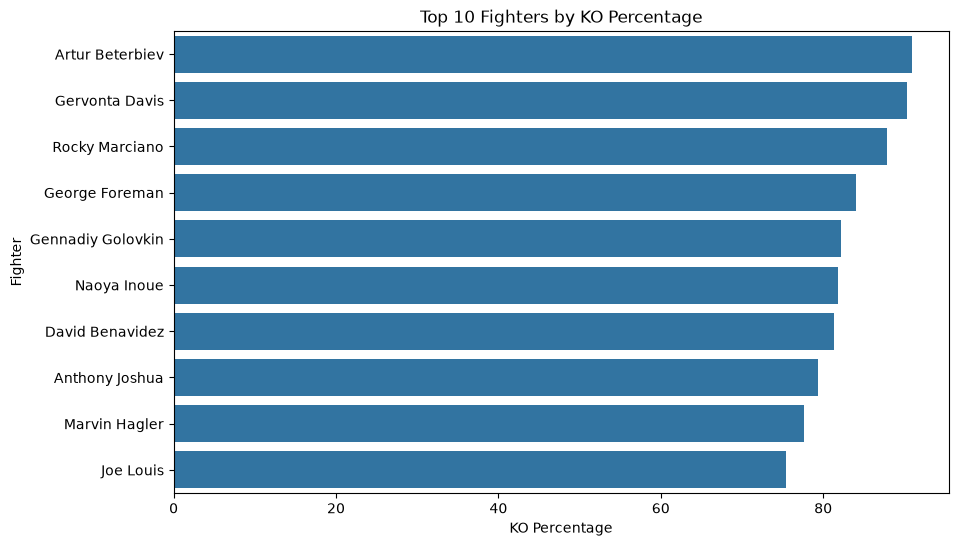

In [95]:
top_10_ko = df.nlargest(10, "KO %")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_ko,
    x="KO %",
    y="Fighter Name"
)

plt.title("Top 10 Fighters by KO Percentage")
plt.xlabel("KO Percentage")
plt.ylabel("Fighter")

plt.show()

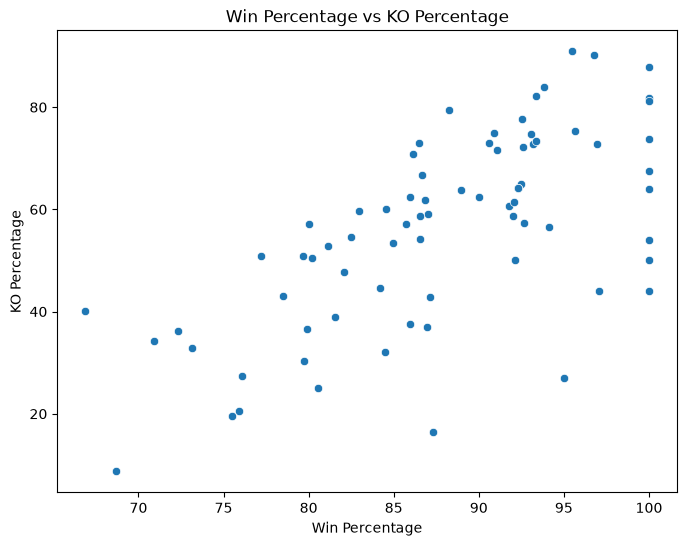

In [96]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Win %",
    y="KO %"
)

plt.title("Win Percentage vs KO Percentage")
plt.xlabel("Win Percentage")
plt.ylabel("KO Percentage")

plt.show()

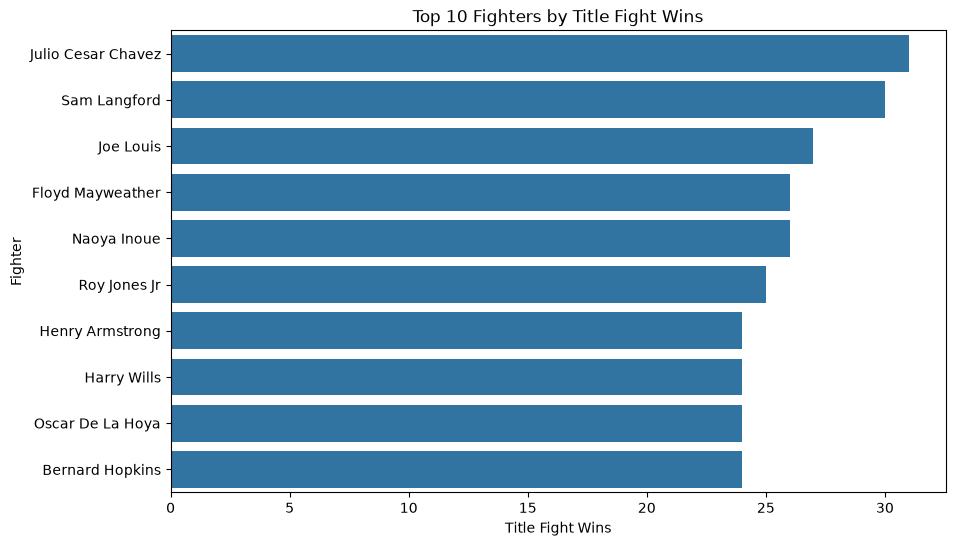

In [97]:
top_10_title_wins = df.nlargest(
    10,
    "Title Fight Wins"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_title_wins,
    x="Title Fight Wins",
    y="Fighter Name"
)

plt.title("Top 10 Fighters by Title Fight Wins")
plt.xlabel("Title Fight Wins")
plt.ylabel("Fighter")

plt.show()

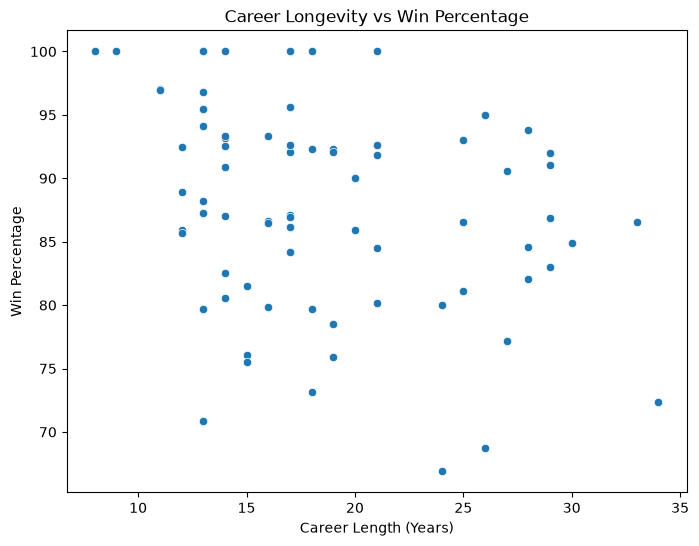

In [103]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Career Length",
    y="Win %"
)

plt.title("Career Longevity vs Win Percentage")
plt.xlabel("Career Length (Years)")
plt.ylabel("Win Percentage")

plt.show()